# Modelling

This notebook trains and evaluates regression models for predicting Drive-End (DE) vibration from steady-state operating windows.

## Imports

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Configuration

In [2]:
DATASET_PATH = Path("steady_state_model_dataset_1min.csv")
FIGURES_DIR = Path("figures")
RESULTS_DIR = Path("model_results")

FEATURES = [
    "power",
    "exciter_current",
    "inlet_pressure",
    "needle_position",
]
TARGET = "de_vibration"
TIME_COLUMN = "start_time"
TEST_SIZE = 0.30
RANDOM_STATE = 42

In [3]:
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
    }


def save_figure(filename):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

## Load Modelling Dataset

In [4]:
model_data = pd.read_csv(
    DATASET_PATH,
    parse_dates=["start_time", "end_time"],
)

print(f"Rows: {len(model_data):,}")
model_data.head()

Rows: 212,374


,operating_period,start_time,end_time,is_steady,interval_id,power,needle_position,exciter_current,inlet_pressure,de_vibration
0,0,2024-06-01 00:00:00,2024-06-01 00:00:50,True,1,9.429999,75.339462,6.948219,3826.189043,0.586103
1,0,2024-06-01 00:01:00,2024-06-01 00:01:50,True,1,9.429999,74.975650,6.953729,3826.189043,0.618846
2,0,2024-06-01 00:02:00,2024-06-01 00:02:50,True,1,9.429999,75.124611,6.959528,3826.189043,0.618846
3,0,2024-06-01 00:03:00,2024-06-01 00:03:50,True,1,9.429999,75.124611,6.954519,3826.189043,0.618846
4,0,2024-06-01 00:04:00,2024-06-01 00:04:50,True,1,9.429999,75.124611,6.950508,3826.189043,0.618846


In [5]:
missing_summary = (
    model_data[FEATURES + [TARGET]]
    .isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)
missing_summary["missing_percent"] = (
    missing_summary["missing_values"] / len(model_data) * 100
).round(3)

missing_summary

,missing_values,missing_percent
power,5309,2.5
exciter_current,5309,2.5
inlet_pressure,5309,2.5
needle_position,5309,2.5
de_vibration,5309,2.5


## Prepare Train and Test Data

The split is chronological so the test set represents later operation, which is closer to how the model would be used in practice.

In [6]:
model_train = (
    model_data
    .dropna(subset=FEATURES + [TARGET, TIME_COLUMN])
    .sort_values(TIME_COLUMN)
    .reset_index(drop=True)
    .copy()
)

split_idx = int(len(model_train) * (1 - TEST_SIZE))

train_df = model_train.iloc[:split_idx].copy()
test_df = model_train.iloc[split_idx:].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

split_summary = pd.DataFrame({
    "set": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "start_time": [train_df[TIME_COLUMN].min(), test_df[TIME_COLUMN].min()],
    "end_time": [train_df[TIME_COLUMN].max(), test_df[TIME_COLUMN].max()],
})

split_summary

,set,rows,start_time,end_time
0,train,144945,2024-06-01 00:00:00,2024-09-16 17:30:00
1,test,62120,2024-09-16 17:31:00,2024-10-30 23:58:20


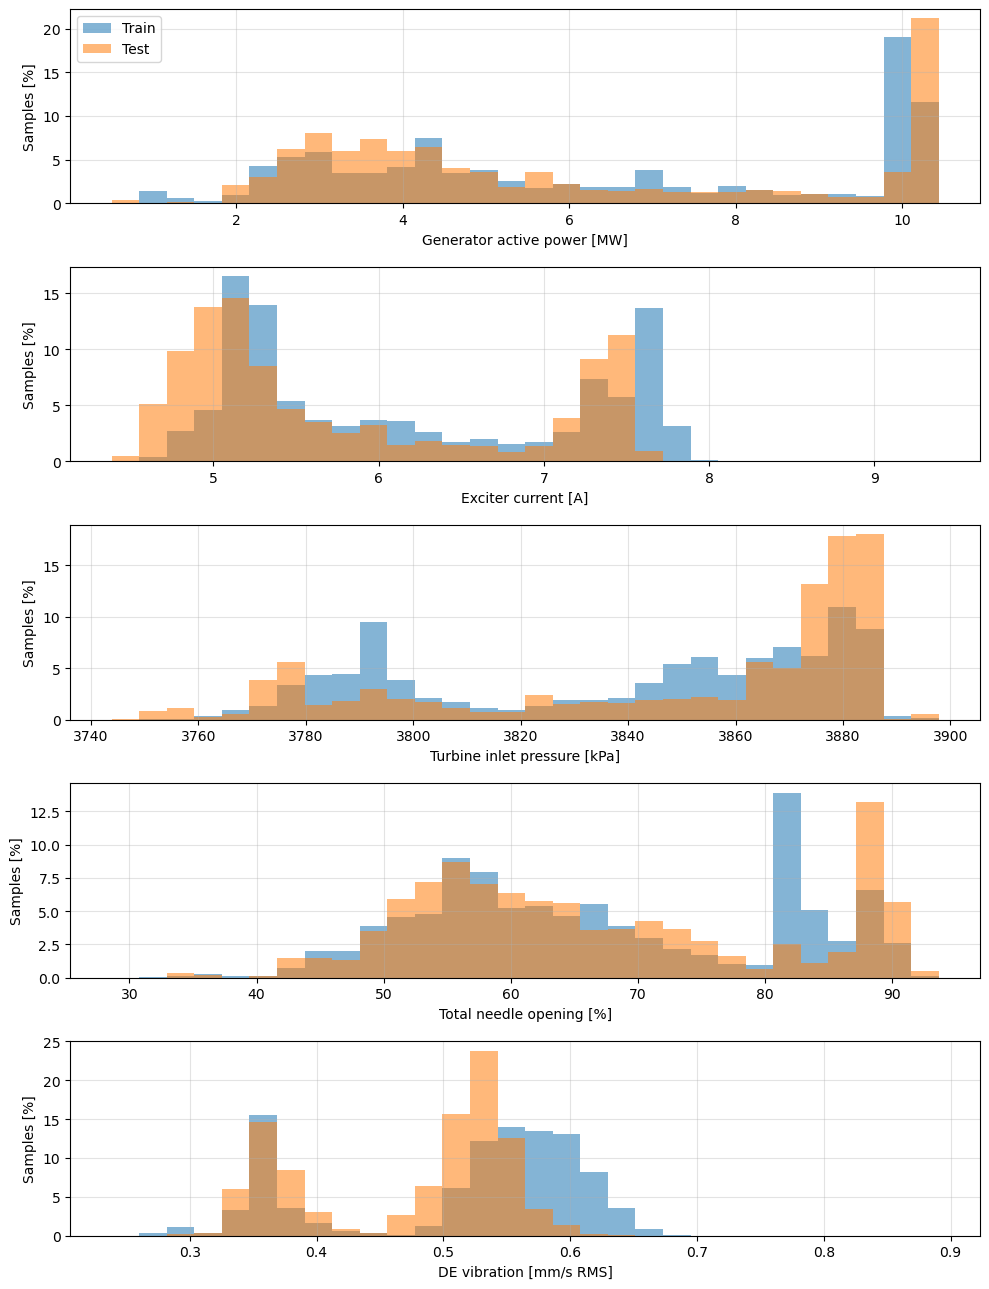

In [7]:
FEATURE_LABELS = {
    "power": "Generator active power",
    "exciter_current": "Exciter current",
    "inlet_pressure": "Turbine inlet pressure",
    "needle_position": "Total needle opening",
    "de_vibration": "DE vibration",
}

FEATURE_UNITS = {
    "power": "MW",
    "exciter_current": "A",
    "inlet_pressure": "kPa",
    "needle_position": "%",
    "de_vibration": "mm/s RMS",
}

columns_to_plot = FEATURES + [TARGET]

fig, axes = plt.subplots(
    len(columns_to_plot),
    1,
    figsize=(10, 13),
    sharey=False,
)

for ax, column in zip(axes, columns_to_plot):
    train_values = train_df[column].dropna().to_numpy()
    test_values = test_df[column].dropna().to_numpy()

    combined = np.concatenate([train_values, test_values])
    bins = np.linspace(combined.min(), combined.max(), 31)

    label = FEATURE_LABELS.get(column, column)
    unit = FEATURE_UNITS.get(column, "")
    xlabel = f"{label} [{unit}]" if unit else label

    ax.hist(
        train_values,
        bins=bins,
        alpha=0.55,
        weights=np.ones(len(train_values)) / len(train_values) * 100,
        label="Train",
    )

    ax.hist(
        test_values,
        bins=bins,
        alpha=0.55,
        weights=np.ones(len(test_values)) / len(test_values) * 100,
        label="Test",
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Samples [%]")
    ax.grid(True, alpha=0.35)

axes[0].legend()
plt.tight_layout()
save_figure("train_test_feature_target_histograms_vertical.png")
plt.show()

## Baseline and Candidate Models

In [8]:
candidate_models = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Linear regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-4, 4, 17))),
    ]),
    "Histogram gradient boosting": HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=250,
        l2_regularization=0.01,
        random_state=RANDOM_STATE,
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=150,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

rows = []
fitted_models = {}

for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    fitted_models[name] = model
    rows.append({"model": name, **regression_metrics(y_test, predictions)})

model_scores = (
    pd.DataFrame(rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
    .round(4)
)

model_scores

,model,MAE,RMSE,R2
0,Histogram gradient boosting,0.0430,0.0582,0.4855
1,Random forest,0.0457,0.0616,0.4244
2,Ridge regression,0.0664,0.0795,0.0418
3,Linear regression,0.0664,0.0795,0.0418
4,Mean baseline,0.0665,0.0911,-0.2584


## Tune ANN Model

In [9]:
ann_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ann", MLPRegressor(
        activation="relu",
        solver="adam",
        max_iter=600,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,
        random_state=RANDOM_STATE,
    )),
])

param_grid = {
    "ann__hidden_layer_sizes": [(16,), (32,), (32, 16), (64, 32)],
    "ann__alpha": [0.0001, 0.001, 0.01],
    "ann__learning_rate_init": [0.001, 0.0005],
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=ann_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

grid_search.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_)

print("Best ANN parameters:")
print(grid_search.best_params_)
print(f"Best CV RMSE: {-grid_search.best_score_:.4f} mm/s RMS")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best ANN parameters:
{'ann__alpha': 0.001, 'ann__hidden_layer_sizes': (16,), 'ann__learning_rate_init': 0.0005}
Best CV RMSE: 0.0380 mm/s RMS


In [10]:
top_ann_models = cv_results.copy()

top_ann_models["CV RMSE"] = -top_ann_models["mean_test_score"]

top_ann_models = (
    top_ann_models[
        [
            "rank_test_score",
            "param_ann__hidden_layer_sizes",
            "param_ann__alpha",
            "param_ann__learning_rate_init",
            "CV RMSE",
        ]
    ]
    .rename(columns={
        "rank_test_score": "Rank",
        "param_ann__hidden_layer_sizes": "Hidden layers",
        "param_ann__alpha": "Alpha",
        "param_ann__learning_rate_init": "Learning rate",
    })
    .sort_values("Rank")
    .head(5)
    .reset_index(drop=True)
)

top_ann_models = top_ann_models.round(4)

top_ann_models

,Rank,Hidden layers,Alpha,Learning rate,CV RMSE
0,1,"(16,)",0.0010,0.0005,0.0380
1,2,"(16,)",0.0001,0.0010,0.0383
2,3,"(16,)",0.0100,0.0005,0.0386
3,4,"(16,)",0.0001,0.0005,0.0389
4,5,"(16,)",0.0010,0.0010,0.0389


## Final Test Evaluation

In [11]:
best_ann = grid_search.best_estimator_
fitted_models["Tuned ANN"] = best_ann

ann_predictions = best_ann.predict(X_test)
ann_scores = {"model": "Tuned ANN", **regression_metrics(y_test, ann_predictions)}

all_scores = (
    pd.concat([model_scores, pd.DataFrame([ann_scores])], ignore_index=True)
    .sort_values("RMSE")
    .reset_index(drop=True)
    .round(4)
)
all_scores

,model,MAE,RMSE,R2
0,Tuned ANN,0.0423,0.0566,0.5139
1,Histogram gradient boosting,0.0430,0.0582,0.4855
2,Random forest,0.0457,0.0616,0.4244
3,Ridge regression,0.0664,0.0795,0.0418
4,Linear regression,0.0664,0.0795,0.0418
5,Mean baseline,0.0665,0.0911,-0.2584


In [14]:
y_pred = best_ann.predict(X_test)
y_baseline = fitted_models["Mean baseline"].predict(X_test)

results = pd.DataFrame({
    "start_time": test_df[TIME_COLUMN].values,
    "actual": y_test.values,
    "predicted": y_pred,
    "baseline": y_baseline,
})
results["residual"] = results["actual"] - results["predicted"]
results["absolute_error"] = results["residual"].abs()

results.head()

,start_time,actual,predicted,baseline,residual,absolute_error
0,2024-09-16 17:31:00,0.529348,0.545798,0.513703,-0.016449,0.016449
1,2024-09-16 17:32:00,0.529348,0.545817,0.513703,-0.016469,0.016469
2,2024-09-16 17:33:00,0.529348,0.550141,0.513703,-0.020792,0.020792
3,2024-09-16 17:34:00,0.529348,0.551938,0.513703,-0.022590,0.022590
4,2024-09-16 17:35:00,0.529348,0.553465,0.513703,-0.024116,0.024116


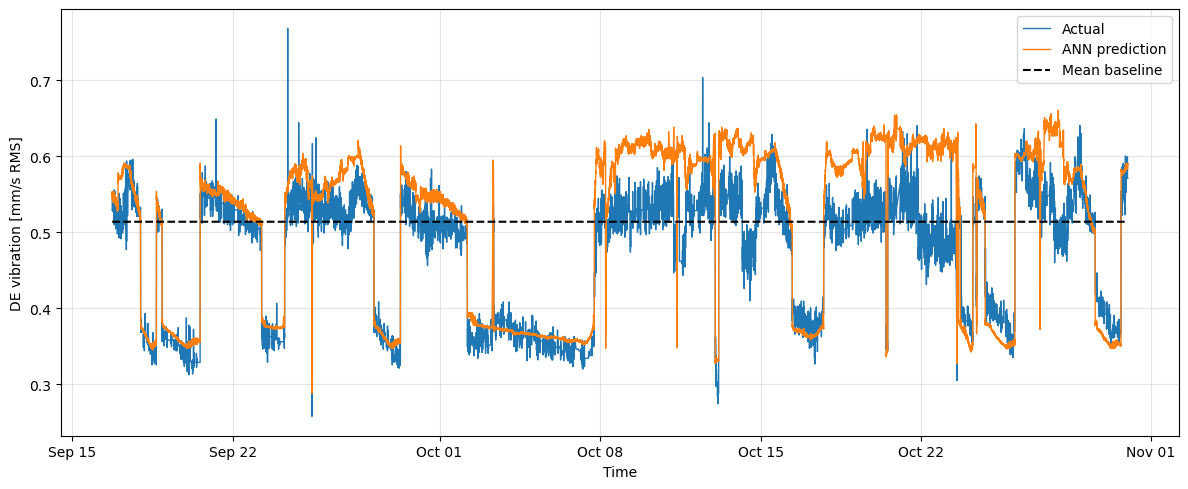

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(results["start_time"], results["actual"], label="Actual", linewidth=1.0)
plt.plot(results["start_time"], results["predicted"], label="ANN prediction", linewidth=1.0)
plt.plot(results["start_time"], results["baseline"], linestyle="--", color="black", label="Mean baseline")

plt.xlabel("Time")
plt.ylabel("DE vibration [mm/s RMS]")
plt.legend()
plt.grid(True, alpha=0.35)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
save_figure("actual_predicted_baseline_test.png")

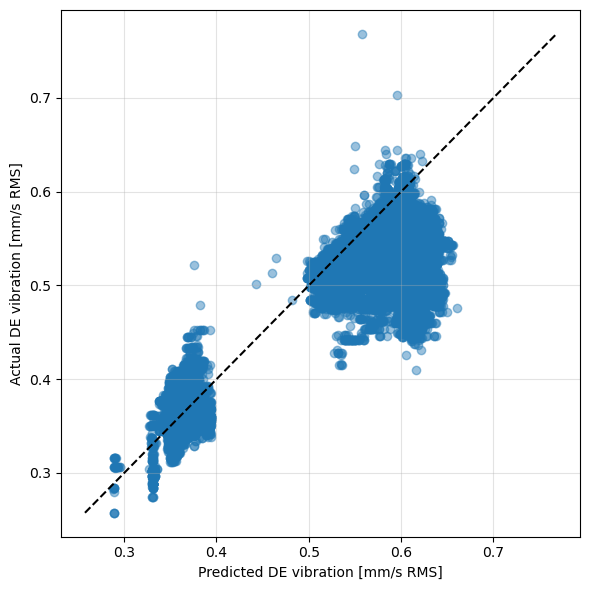

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(results["predicted"], results["actual"], alpha=0.45)

min_val = min(results["actual"].min(), results["predicted"].min())
max_val = max(results["actual"].max(), results["predicted"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black")

plt.xlabel("Predicted DE vibration [mm/s RMS]")
plt.ylabel("Actual DE vibration [mm/s RMS]")
plt.grid(True, alpha=0.35)
save_figure("actual_vs_predicted_scatter.png")

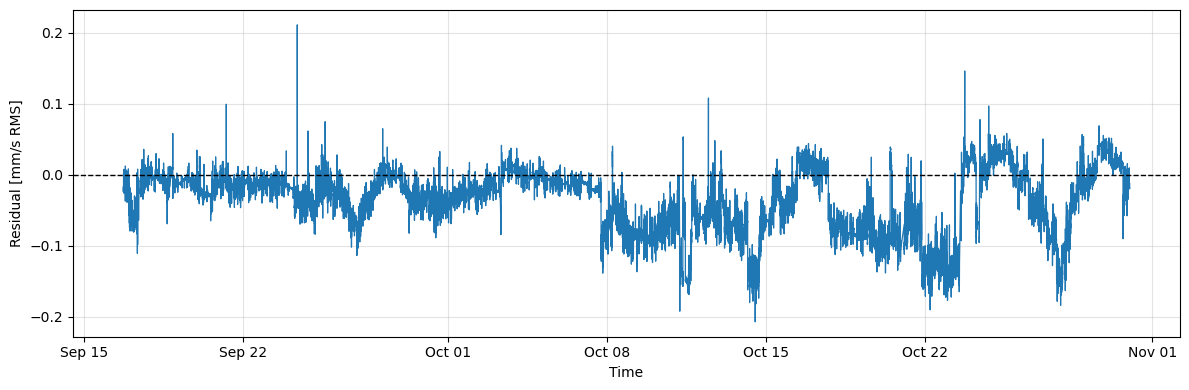

In [18]:
# Residuals over time
plt.figure(figsize=(12, 4))

plt.plot(results["start_time"], results["residual"], linewidth=0.9)
plt.axhline(0, color="black", linestyle="--", linewidth=1.0)

plt.xlabel("Time")
plt.ylabel("Residual [mm/s RMS]")
plt.grid(True, alpha=0.35)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
save_figure("ann_residuals_test.png")
plt.show()

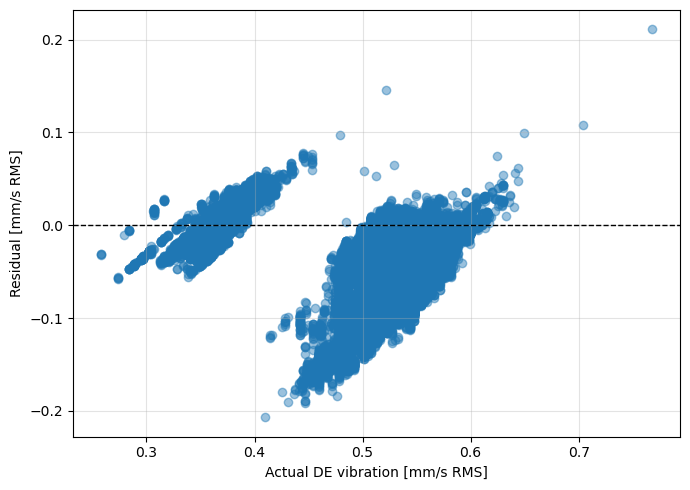

In [19]:
# Residuals versus actual vibration
plt.figure(figsize=(7, 5))

plt.scatter(results["actual"], results["residual"], alpha=0.45)
plt.axhline(0, color="black", linestyle="--", linewidth=1.0)

plt.xlabel("Actual DE vibration [mm/s RMS]")
plt.ylabel("Residual [mm/s RMS]")
plt.grid(True, alpha=0.35)

plt.tight_layout()
save_figure("residuals_vs_actual_vibration.png")
plt.show()

## Error by Vibration Level

In [20]:
bin_edges = np.array([0.25, 0.35, 0.45, 0.55, 0.65, 0.80])
error_df = results.copy()
error_df["squared_error"] = error_df["residual"] ** 2
error_df["vibration_bin"] = pd.cut(error_df["actual"], bins=bin_edges)

bin_errors = error_df.groupby("vibration_bin", observed=False).agg(
    n_samples=("absolute_error", "count"),
    mean_actual=("actual", "mean"),
    mean_prediction=("predicted", "mean"),
    mean_residual=("residual", "mean"),
    mae=("absolute_error", "mean"),
    rmse=("squared_error", lambda x: np.sqrt(np.mean(x))),
)
bin_errors["percentage_of_test"] = bin_errors["n_samples"] / len(error_df) * 100
bin_errors

,n_samples,mean_actual,mean_prediction,mean_residual,mae,rmse,percentage_of_test
vibration_bin,,,,,,,
"(0.25, 0.35]",5277,0.338306,0.356119,-0.017813,0.018038,0.020036,8.494849
"(0.35, 0.45]",15704,0.373392,0.368761,0.004631,0.016033,0.022760,25.280103
"(0.45, 0.55]",34021,0.519133,0.579040,-0.059907,0.060441,0.072414,54.766581
"(0.55, 0.65]",7116,0.567095,0.596014,-0.028919,0.031555,0.038090,11.455248
"(0.65, 0.8]",2,0.735904,0.576321,0.159583,0.159583,0.167678,0.003220


## Feature Importance

In [17]:
sample_size = min(20_000, len(X_test))
X_importance = X_test.sample(sample_size, random_state=RANDOM_STATE)
y_importance = y_test.loc[X_importance.index]

importance = permutation_importance(
    best_ann,
    X_importance,
    y_importance,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame({
        "feature": FEATURES,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
importance_df

,feature,importance_mean,importance_std
0,power,0.160355,0.000578
1,exciter_current,0.123343,0.000539
2,needle_position,0.073184,0.000441
3,inlet_pressure,0.001002,0.000146


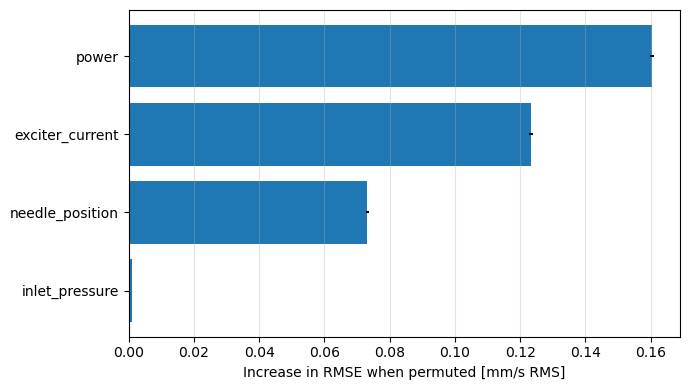

In [18]:
plt.figure(figsize=(7, 4))
plt.barh(
    importance_df["feature"],
    importance_df["importance_mean"],
    xerr=importance_df["importance_std"],
)
plt.gca().invert_yaxis()
plt.xlabel("Increase in RMSE when permuted [mm/s RMS]")
plt.grid(True, axis="x", alpha=0.35)
save_figure("permutation_importance.png")

## Model Use

Use `all_scores` for the headline model comparison, `results` for the held-out test predictions, and `importance_df` to discuss which operating signals contribute most to the vibration prediction.

## Tuned ANN: First Test Observation

Evaluate the tuned ANN on the first row of the held-out test set.

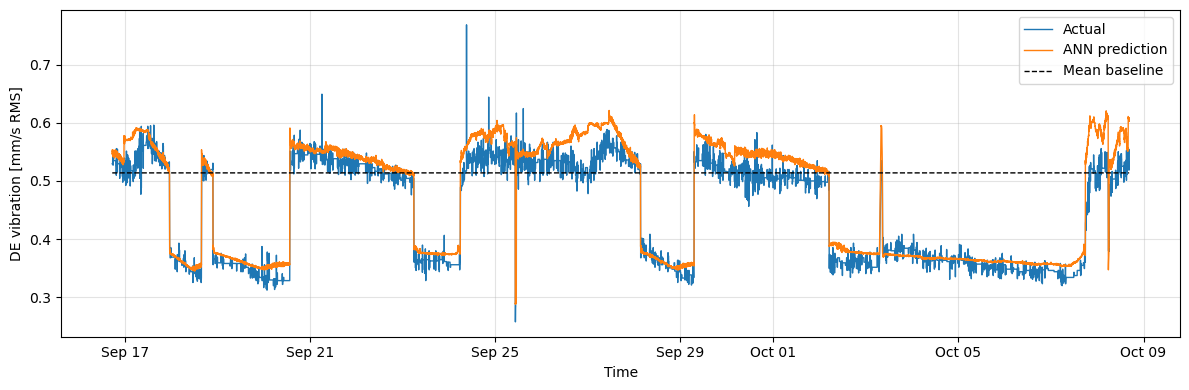

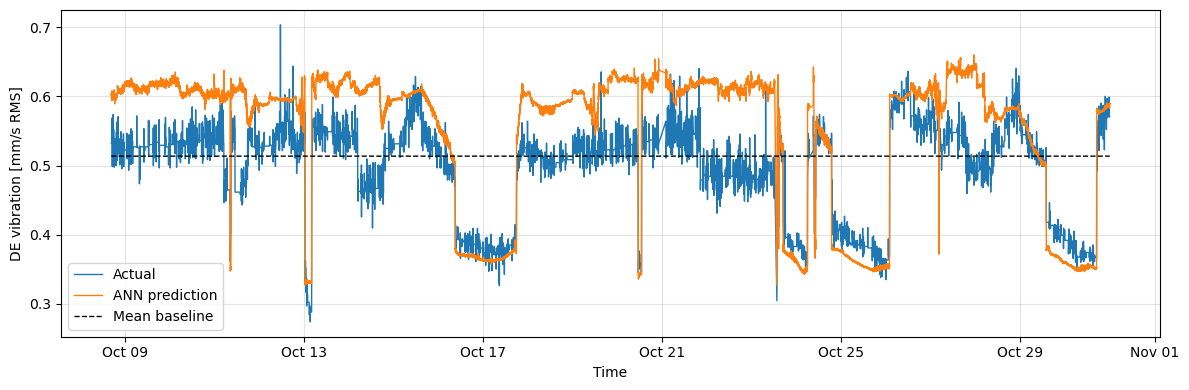

,Test subset,Model,MAE,RMSE,R2
0,First half,Mean baseline,0.0830,0.1092,-0.5842
1,First half,ANN,0.0224,0.0296,0.8839
2,Second half,Mean baseline,0.0501,0.0684,-0.0600
3,Second half,ANN,0.0622,0.0744,-0.2547


In [20]:
n_half = len(results) // 2

test_halves = {
    "First half": results.iloc[:n_half],
    "Second half": results.iloc[n_half:],
}

half_scores = []

for subset_name, subset in test_halves.items():
    half_scores.append({
        "Test subset": subset_name,
        "Model": "Mean baseline",
        **regression_metrics(subset["actual"], subset["baseline"]),
    })

    half_scores.append({
        "Test subset": subset_name,
        "Model": "ANN",
        **regression_metrics(subset["actual"], subset["predicted"]),
    })

    plt.figure(figsize=(12, 4))

    plt.plot(
        subset["start_time"],
        subset["actual"],
        label="Actual",
        linewidth=1.0,
    )

    plt.plot(
        subset["start_time"],
        subset["predicted"],
        label="ANN prediction",
        linewidth=1.0,
    )

    plt.plot(
        subset["start_time"],
        subset["baseline"],
        linestyle="--",
        color="black",
        label="Mean baseline",
        linewidth=1.0,
    )

    plt.xlabel("Time")
    plt.ylabel("DE vibration [mm/s RMS]")
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()

half_scores = pd.DataFrame(half_scores).round(4)

half_scores